In [ ]:
import os
dataset_path = "/content/drive/MyDrive/Colab Notebooks"
print("--- Daftar File di Drive  ---")
files = os.listdir(dataset_path)
for f in files:
    if f.endswith('.npy') or f.endswith('.joblib'):
        print(f"- {f}")

--- Daftar File di Drive  ---
- train_benign_clean.npy
- dataset_split.joblib


[INFO] Memuat dataset dari Drive...
[INFO] Data siap! Melatih model pada 11296017 baris...


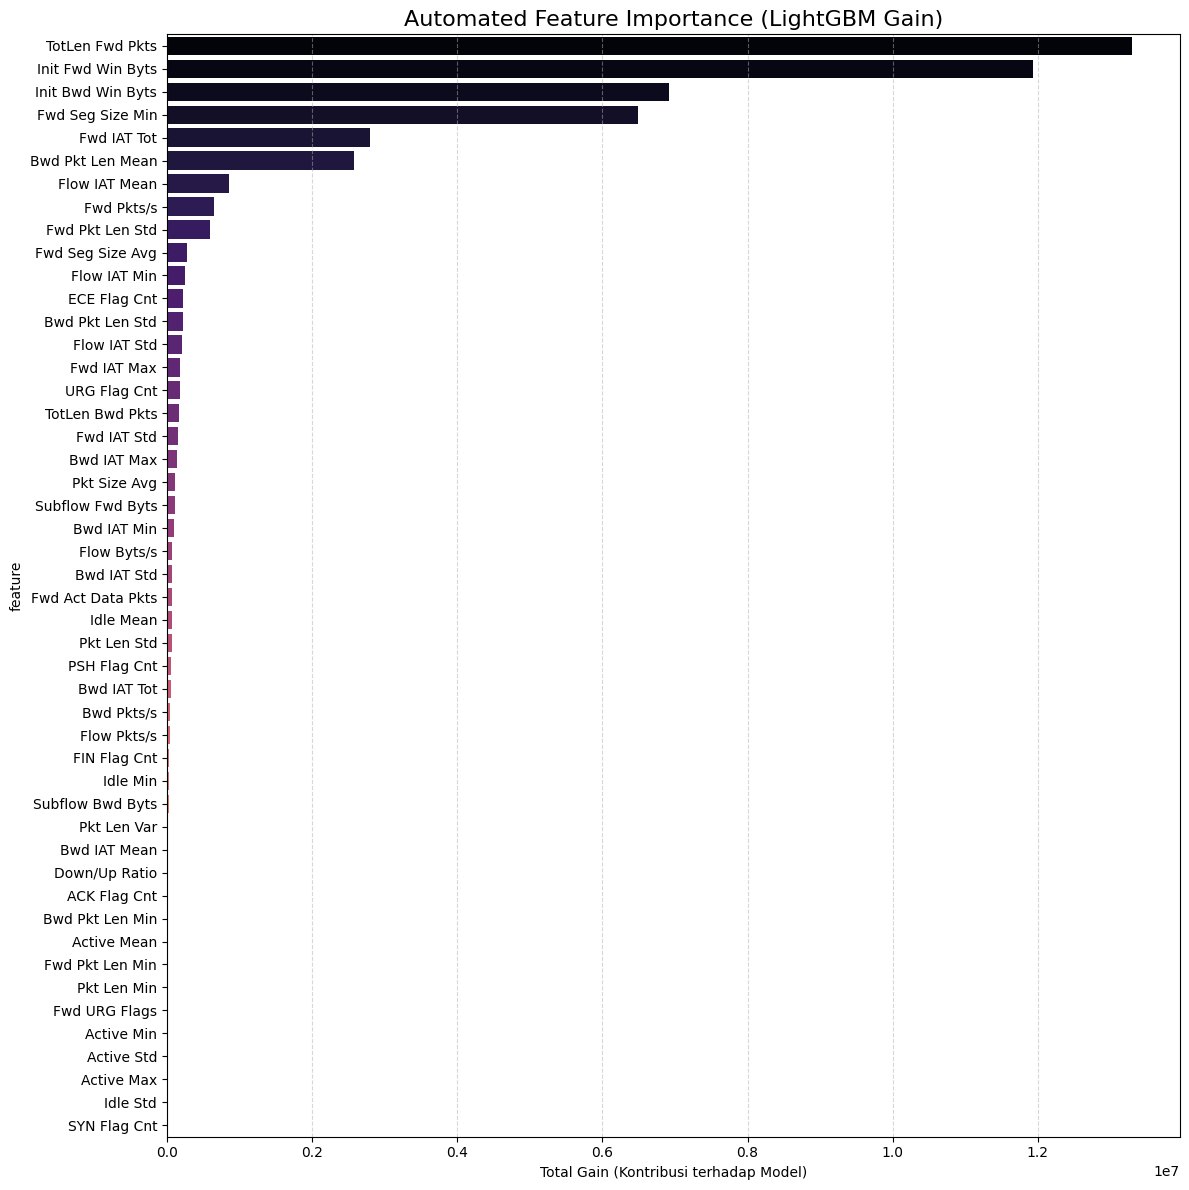


--- HASIL DETEKSI OTOMATIS ---
Total fitur yang dianalisis: 48
Fitur yang terdeteksi 'Loyo/Toxic' (Importance <= 13293.95):
['Pkt Len Var', 'Bwd IAT Mean', 'Down/Up Ratio', 'ACK Flag Cnt', 'Bwd Pkt Len Min', 'Active Mean', 'Fwd Pkt Len Min', 'Pkt Len Min', 'Fwd URG Flags', 'Active Min', 'Active Std', 'Active Max', 'Idle Std', 'SYN Flag Cnt']


In [ ]:
import joblib
import os
import lightgbm as lgb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dataset_path = "/content/drive/MyDrive/Colab Notebooks"
split_file = os.path.join(dataset_path, "dataset_split.joblib")

print("[INFO] Memuat dataset dari Drive...")
data = joblib.load(split_file)

X_train = data['X_train']
y_train = data['y_train']
features = data['features']

print(f"[INFO] Data siap! Melatih model pada {X_train.shape[0]} baris...")

train_data = lgb.Dataset(X_train, label=y_train, feature_name=features)

params = {
    'objective': 'binary',
    'metric': 'auc',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'random_state': 42
}

lgbm_model = lgb.train(params, train_data, num_boost_round=100)

importance_df = pd.DataFrame({
    'feature': features,
    'importance': lgbm_model.feature_importance(importance_type='gain')
}).sort_values(by='importance', ascending=False)

threshold = importance_df['importance'].max() * 0.001
toxic_auto = importance_df[importance_df['importance'] <= threshold]

plt.figure(figsize=(12, 12))
sns.barplot(x='importance', y='feature', data=importance_df, palette='magma', hue='feature', legend=False)
plt.title('Automated Feature Importance (LightGBM Gain)', fontsize=16)
plt.xlabel('Total Gain (Kontribusi terhadap Model)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"\n--- HASIL DETEKSI OTOMATIS ---")
print(f"Total fitur yang dianalisis: {len(features)}")
print(f"Fitur yang terdeteksi 'Loyo/Toxic' (Importance <= {threshold:.2f}):")
print(toxic_auto['feature'].tolist())

In [ ]:
import joblib, os, gc
import numpy as np
from sklearn.utils import class_weight

dataset_path = "/content/drive/MyDrive/Colab Notebooks"
split_file = os.path.join(dataset_path, "dataset_split.joblib")

print("[INFO] Memuat ulang dataset_split.joblib...")
data = joblib.load(split_file)

feat_names = data['features']
toxic = [
    'Pkt Len Var', 'Bwd IAT Mean', 'Down/Up Ratio', 'ACK Flag Cnt',
    'Bwd Pkt Len Min', 'Active Mean', 'Fwd Pkt Len Min', 'Pkt Len Min',
    'Fwd URG Flags', 'Active Min', 'Active Std', 'Active Max',
    'Idle Std', 'SYN Flag Cnt'
]

healthy_idx = [i for i, f in enumerate(feat_names) if f not in toxic]
healthy_names = [f for f in feat_names if f not in toxic]

print(f"[INFO] Menghapus {len(toxic)} fitur toxic...")
print(f"[INFO] Menggunakan {len(healthy_idx)} fitur sehat...")

X_train = data['X_train'][:, healthy_idx].astype('float32')
y_train = data['y_train']

X_val = data['X_val'][:, healthy_idx].astype('float32')
y_val = data['y_val']

X_test = data['X_test'][:, healthy_idx].astype('float32')
y_test = data['y_test']

del data
gc.collect()

weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = {0: weights[0], 1: weights[1]}

print("\n" + "="*55)
print(f"DATA READY")
print("="*55)
print(f"Jumlah Fitur Final : {X_train.shape[1]}")
print(f"Data Training      : {X_train.shape[0]:,} baris")
print(f"Data Validation    : {X_val.shape[0]:,} baris")
print(f"Data Testing       : {X_test.shape[0]:,} baris")
print(f"Bobot Kelas        : {class_weights}")
print("="*55)

[INFO] Memuat ulang dataset_split.joblib...
[INFO] Menghapus 14 fitur toxic...
[INFO] Menggunakan 34 fitur sehat...

DATA READY
Jumlah Fitur Final : 34
Data Training      : 11,296,017 baris
Data Validation    : 2,420,575 baris
Data Testing       : 2,420,576 baris
Bobot Kelas        : {0: np.float64(0.6025723120359691), 1: np.float64(2.937304912385444)}


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
import numpy as np

tune_idx = np.random.choice(len(X_train), int(len(X_train) * 0.05), replace=False)
X_tune = X_train[tune_idx]
y_tune = y_train[tune_idx]

param_dist = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

rf_base = RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

print("Memulai Hyperparameter Tuning pada subset data...")
random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='roc_auc',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_tune, y_tune)

print(f"\nParameter Terbaik: {random_search.best_params_}")
best_rf = random_search.best_estimator_

Memulai Hyperparameter Tuning pada subset data...
Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Parameter Terbaik: {'n_estimators': 100, 'min_samples_split': 10, 'max_features': 'log2', 'max_depth': 20}


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import time

print("[INFO] Melatih model RF dengan parameter optimal pada data penuh...")
best_rf = RandomForestClassifier(
    n_estimators=100,
    min_samples_split=10,
    max_features='log2',
    max_depth=20,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

start_t = time.time()
best_rf.fit(X_train, y_train)
end_t = time.time()

print(f"\nTraining selesai dalam {end_t - start_t:.2f} detik.")

print("Menghitung skor AUC untuk analisis fitting...")
train_probs = best_rf.predict_proba(X_train)[:, 1]
val_probs = best_rf.predict_proba(X_val)[:, 1]

train_auc = roc_auc_score(y_train, train_probs)
val_auc = roc_auc_score(y_val, val_probs)

print("\n" + "="*35)
print(f"   HASIL AUDIT FITTING MODEL RF")
print("="*35)
print(f"Training AUC   : {train_auc:.4f}")
print(f"Validation AUC : {val_auc:.4f}")
print(f"Selisih  : {abs(train_auc - val_auc):.4f}")
print("-" * 35)

# Penentuan Status
if abs(train_auc - val_auc) > 0.02:
    status = "POTENSI OVERFITTING"
elif train_auc < 0.90:
    status = "POTENSI UNDERFITTING"
else:
    status = "MODEL FIT"

print(f"STATUS: {status}")
print("="*35)

[INFO] Melatih model RF dengan parameter optimal pada data penuh...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed: 33.9min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed: 73.0min finished



Training selesai dalam 4389.77 detik.
Menghitung skor AUC untuk analisis fitting...


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:  1.8min
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:  3.8min finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:   21.7s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:   48.0s finished



   HASIL AUDIT FITTING MODEL RF
Training AUC   : 0.9942
Validation AUC : 0.9913
Selisih  : 0.0030
-----------------------------------
STATUS: MODEL FIT


Melakukan prediksi pada data test...


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:   26.2s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:   50.3s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:   19.9s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:   42.4s finished



==================== RF FINAL REPORT ====================
              precision    recall  f1-score   support

      Benign     0.9911    0.9920    0.9915   2008536
      Attack     0.9609    0.9565    0.9587    412040

    accuracy                         0.9860   2420576
   macro avg     0.9760    0.9743    0.9751   2420576
weighted avg     0.9859    0.9860    0.9860   2420576



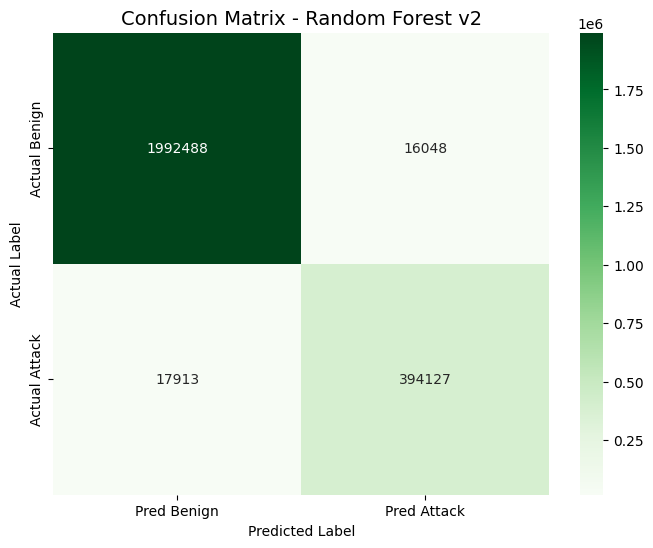

FPR Random Forest: 0.007990 (0.7990%)


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prediksi pada Data Test
print("Melakukan prediksi pada data test...")
y_pred_rf = best_rf.predict(X_test)
y_pred_prob_rf = best_rf.predict_proba(X_test)[:, 1]

# 2. Classification Report
print("\n" + "="*20 + " RF FINAL REPORT " + "="*20)
print(classification_report(y_test, y_pred_rf, target_names=['Benign', 'Attack'], digits=4))

# 3. Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Pred Benign', 'Pred Attack'],
            yticklabels=['Actual Benign', 'Actual Attack'])
plt.title('Confusion Matrix - Random Forest v2', fontsize=14)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# 4. Hitung FPR untuk RF
tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()
fpr_rf = fp_rf / (fp_rf + tn_rf)
print(f"FPR Random Forest: {fpr_rf:.6f} ({fpr_rf*100:.4f}%)")

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# 1. Prediksi
y_pred_rf = best_rf.predict(X_test)
y_pred_prob_rf = best_rf.predict_proba(X_test)[:, 1]

# 2. Analisis Error
tn_rf, fp_rf, fn_rf, tp_rf = confusion_matrix(y_test, y_pred_rf).ravel()
fpr_rf = fp_rf / (fp_rf + tn_rf)

print("="*30)
print(f"ANALISIS ERROR RANDOM FOREST")
print("="*30)
print(f"FPR (False Positive Rate) : {fpr_rf:.6f} ({fpr_rf*100:.4f}%)")
print(f"Detection Rate (Recall)   : {tp_rf/(tp_rf+fn_rf)*100:.2f}%")
print("="*30)

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:   23.3s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:  1.0min finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:   31.2s


ANALISIS ERROR RANDOM FOREST
FPR (False Positive Rate) : 0.007990 (0.7990%)
Detection Rate (Recall)   : 95.65%


[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:  1.0min finished


In [ ]:
def zero_day_detector_rf(data_point):
    # A. Prediksi RF
    prob = best_rf.predict_proba(data_point.reshape(1, -1))[:, 1][0]
    rf_label = "ATTACK" if prob >= 0.5 else "BENIGN"

    # B. Cek Anomali
    is_normal = iso_forest.predict(data_point.reshape(1, -1))[0]

    status = "Normal"
    if rf_label == "BENIGN" and is_normal == -1:
        status = "POTENSI ZERO-DAY"
    elif rf_label == "ATTACK":
        status = "SERANGAN TERDETEKSI"
    else:
        status = "TRAFIK NORMAL"

    return status, prob, is_normal

In [ ]:
from sklearn.ensemble import IsolationForest

print("Melatih modul deteksi anomali untuk notebook RF...")

X_benign_train = X_train[y_train == 0]

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.01,
    random_state=42,
    n_jobs=-1
)
iso_forest.fit(X_benign_train)
print("Isolation Forest siap digunakan!")

Melatih modul deteksi anomali untuk notebook RF...
Isolation Forest siap digunakan!


In [ ]:
print("Menyisir celah pada Random Forest...")

missed_by_rf = np.where((y_test == 1) & (y_pred_rf == 0))[0]

print(f"Total serangan yang lolos dari RF: {len(missed_by_rf)} data.")

if len(missed_by_rf) > 0:
    saved_rf = 0
    for idx in missed_by_rf:
        is_normal = iso_forest.predict(X_test[idx].reshape(1, -1))[0]
        if is_normal == -1:
            saved_rf += 1

    print(f"HASIL: Dari {len(missed_by_rf)} serangan yang lolos, {saved_rf} tertangkap ANOMALI!")
else:
    print("RF tidak meloloskan serangan.")

Menyisir celah pada Random Forest...
Total serangan yang lolos dari RF: 17913 data.
HASIL: Dari 17913 serangan yang lolos, 163 tertangkap ANOMALI!
